In [2]:
import sys
from pathlib import Path
from matplotlib import pyplot as plt
# ensure parent directory is on sys.path so we can import the nn package
sys.path.insert(0, str(Path('..').resolve()))

from nn.sequential import Sequential
from nn.linear import Linear
from nn.sigmoid import Sigmoid
from nn.relu import ReLU
from nn.losses import BinaryCrossEntropyLoss
from nn.optimizers import SGD
import numpy as np

In [3]:
# generate a random dataset for XOR problem
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

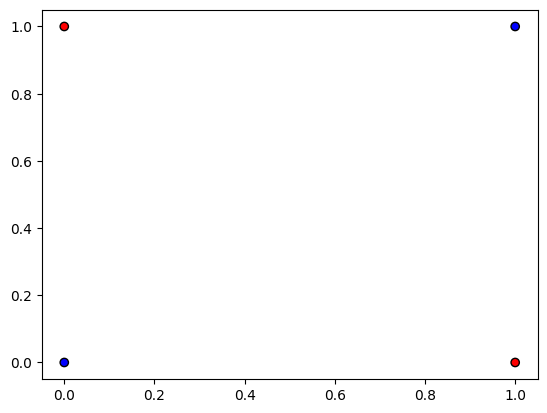

In [4]:
plt.scatter(x[:, 0], x[:, 1], c=y.flatten(), cmap='bwr', edgecolors='k')


In [6]:
np.random.seed(42)
model = Sequential(
    Linear(2, 4),
    ReLU(),
    Linear(4, 1),
    Sigmoid()
)
loss = BinaryCrossEntropyLoss()
optimizer = SGD(learning_rate=0.01)

for epoch in range(10000):
    # forward pass
    y_pred = model.forward(x)
    # compute loss
    loss_value = loss.forward(y, y_pred)
    # backward pass
    grad_output = loss.backward()
    model.backward(grad_output)
    # update parameters
    optimizer.step(model.parameters(), model.gradients())
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss_value}')
    
# compute final predictions and accuracy
print("X", x)
print("Y", y)
y_pred_final = model.forward(x)
print("Y_pred", y_pred_final)

accuracy = np.mean((y_pred_final > 0.5) == y)
print(f'Final Accuracy: {accuracy}')

Epoch 0, Loss: 1.6512161161153667
Epoch 1000, Loss: 0.3215239263547306
Epoch 2000, Loss: 0.17584494721438257
Epoch 3000, Loss: 0.1082122541105662
Epoch 4000, Loss: 0.0747278200561085
Epoch 5000, Loss: 0.055798476281755424
Epoch 6000, Loss: 0.044179746204995964
Epoch 7000, Loss: 0.03640439449611084
Epoch 8000, Loss: 0.03084341010693068
Epoch 9000, Loss: 0.026671539857717117
X [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Y [[0]
 [1]
 [1]
 [0]]
Y_pred [[0.01232669]
 [0.94073324]
 [0.99118282]
 [0.01137943]]
Final Accuracy: 1.0
